# L5d Lab: Minimum-Cost Assignment as a Flow Linear Program

In the [maximum-flow sensitivity lab](../L5b/CHEME-5800-L5b-Lab-MaximumFlowSensitivity-Fall-2026.ipynb), we studied how capacities limit the number of completed assignments. Suppose each available worker–task pairing also has a cost. We now want to complete a specified number of tasks at the lowest total cost, while respecting worker availability and task capacities.

> __Learning Objectives:__
>
> By the end of this lab, you should be able to:
>
> * __Formulate an assignment flow model:__ Translate a worker–task network into a linear program by constructing the incidence matrix, required-flow vector, objective, and bounds. Explain how these components enforce conservation, limit assignments, and account for the cost of completing tasks.
> * __Solve and verify the allocation:__ Compute the minimum-cost flow and translate its edge flows into worker–task assignments. Check capacities and node balances, recompute the total cost, and distinguish a feasible assignment from a minimum-cost assignment.
> * __Analyze unavailable assignments:__ Block a worker–task edge, re-solve for the same required flow, and explain why one lost option can move several workers. Use a sweep over every worker–task edge to identify which assignments the solution depends on, and recognize when a restriction makes the required flow infeasible.

In this lab, we work with three workers and four tasks. Each worker can complete at most one task, and each task can be assigned to at most one worker. We require three completed tasks, then make worker–task pairings unavailable and examine how the cost and the assignments respond.

Let's get started!


___

## Setup, Data, and Prerequisites

First, we load the local [`Include.jl`](Include.jl) setup file and its required packages.

> __Include:__ The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates [`Include.jl`](Include.jl) in the notebook's global scope. The setup file activates the course project, defines local paths, and loads the course library, this lab's minimum-cost-flow helpers, and the packages used here.

Let's set up our code environment:


In [1]:
# Load packages and paths from this notebook's local setup file -
include(joinpath(@__DIR__, "Include.jl"))

# Choose one theme; after changing it, rerun this cell and the plotting cells.
# A single figure can override this choice with the keyword theme = :dark -
theme(:default)   # light background
# theme(:dark)   # dark background


See the [Julia documentation](https://docs.julialang.org/en/v1/) and the [CHEME 5800 course library documentation](https://varnerlab.org/CHEME-5800-CourseRepository-Fall-2026/dev/library/) for the functions and types used here. The local routines for assembling, solving, and validating this lab's flow model are supplied in [src/Compute.jl](src/Compute.jl).


### Network and edge data

The [edge-list file](data/Workers-Tasks-MCMF-Bipartite.edgelist) contains 23 directed edges connecting 13 nodes. We use the following node identifiers:

<table style="margin-left: 0; margin-right: auto; text-align: left;">
<thead><tr><th style="text-align: left;">Nodes</th><th style="text-align: left;">Role in the assignment model</th></tr></thead>
<tbody>
<tr><td style="text-align: left;">1</td><td style="text-align: left;">The source supplies flow to allocate work.</td></tr>
<tr><td style="text-align: left;">2–4</td><td style="text-align: left;">Three workers receive flow from the source.</td></tr>
<tr><td style="text-align: left;">5–8</td><td style="text-align: left;">Four tasks receive flow from their assigned workers.</td></tr>
<tr><td style="text-align: left;">9–12</td><td style="text-align: left;">Task-completion nodes pass flow toward the sink; they correspond to tasks 5–8, respectively.</td></tr>
<tr><td style="text-align: left;">13</td><td style="text-align: left;">The sink collects the total completed work.</td></tr>
</tbody>
</table>

For example, one unit of flow along `1 → 2 → 5 → 9 → 13` represents worker `2` completing task `5`. The passage through node `9` records completion of that same task. Conservation requires the flow entering each intermediate node to equal the flow leaving it.

Every worker is connected to every task in the supplied network. All edges have a lower bound of zero and an upper capacity of one assignment. The source-to-worker edges limit each worker to one assignment; the task-to-completion edges limit the total assigned to each task to one unit.

Each edge record supplies the information needed to construct the model:

> __Edge records:__ The five comma-separated fields are `source, target, cost, lower capacity, upper capacity`. Flow and capacity bounds are measured in assignments; costs are measured in synthetic cost units per assignment. For example, `2,5,1,0,1` allows up to one unit of flow from worker `2` to task `5`, at a cost of one cost unit per assignment.

Worker–task costs differ across the available pairings. Each task-to-completion edge adds one cost unit per assignment, while the source-to-worker and completion-to-sink edges have zero cost. The objective will therefore include both the assignment and completion costs along each selected route.

We will use these node roles and edge records to assemble the linear program in Task 1.


### Drawing positions and data loading

The matrix below stores the node positions for the network figure: row `i` gives the horizontal and vertical coordinates of node `i`. These coordinates control the drawing layout; the edge data determine the optimization model.


In [2]:
# Set the drawing coordinates; row v gives node v's (x, y) position -
node_coordinates = [
    10.0 10.0; # source: node 1
    11.0 11.0; 11.0 10.0; 11.0 9.0; # workers: nodes 2–4
    13.0 11.0; 13.0 10.0; 13.0 9.0; 13.0 8.0; # tasks: nodes 5–8
    14.0 11.0; 14.0 10.0; 14.0 9.0; 14.0 8.0; # completion: nodes 9–12
    15.0 10.0; # sink: node 13
]


13×2 Matrix{Float64}:
 10.0  10.0
 11.0  11.0
 11.0  10.0
 11.0   9.0
 13.0  11.0
 13.0  10.0
 13.0   9.0
 13.0   8.0
 14.0  11.0
 14.0  10.0
 14.0   9.0
 14.0   8.0
 15.0  10.0

Next, we read the [edge-list file](data/Workers-Tasks-MCMF-Bipartite.edgelist) into `edges`. Each entry stores one directed edge's endpoints, cost, and flow bounds in the same order as the file's records.


In [3]:
# Read directed edges with their costs and lower/upper flow bounds -
edge_path = joinpath(CHEME5800_L5D_DATA, "Workers-Tasks-MCMF-Bipartite.edgelist")
edges = read_flow_edges(edge_path) # file order also sets the order of the flow variables


23-element Vector{FlowEdge}:
 FlowEdge(1, 2, 0.0, 0.0, 1.0)
 FlowEdge(1, 3, 0.0, 0.0, 1.0)
 FlowEdge(1, 4, 0.0, 0.0, 1.0)
 FlowEdge(5, 9, 1.0, 0.0, 1.0)
 FlowEdge(6, 10, 1.0, 0.0, 1.0)
 FlowEdge(7, 11, 1.0, 0.0, 1.0)
 FlowEdge(8, 12, 1.0, 0.0, 1.0)
 FlowEdge(9, 13, 0.0, 0.0, 1.0)
 FlowEdge(10, 13, 0.0, 0.0, 1.0)
 FlowEdge(11, 13, 0.0, 0.0, 1.0)
 FlowEdge(12, 13, 0.0, 0.0, 1.0)
 FlowEdge(2, 5, 1.0, 0.0, 1.0)
 FlowEdge(2, 6, 4.0, 0.0, 1.0)
 FlowEdge(2, 7, 6.0, 0.0, 1.0)
 FlowEdge(2, 8, 3.0, 0.0, 1.0)
 FlowEdge(3, 5, 5.0, 0.0, 1.0)
 FlowEdge(3, 6, 1.0, 0.0, 1.0)
 FlowEdge(3, 7, 4.0, 0.0, 1.0)
 FlowEdge(3, 8, 2.0, 0.0, 1.0)
 FlowEdge(4, 5, 4.0, 0.0, 1.0)
 FlowEdge(4, 6, 3.0, 0.0, 1.0)
 FlowEdge(4, 7, 1.0, 0.0, 1.0)
 FlowEdge(4, 8, 5.0, 0.0, 1.0)

___

## Task 1: Assemble the linear program

In this task, we assemble the objective, conservation equations, and flow bounds for the assignment network. We use the inflow-minus-outflow convention from the [linear-programming lecture](../L5c/CHEME-5800-L5c-Lecture-LinearProgramming-Fall-2026.ipynb) and specify how many assignments must be completed.

### From node balances to a matrix equation

Let $f_{u,v}$ denote the flow on the directed edge from node $u$ to node $v$, measured in assignments. At worker `2`, the incoming flow must equal the total sent to tasks. At task `5`, the incoming worker flows must equal the flow sent to its completion node. These balances are given by:
$$
\begin{aligned}
\text{Worker 2:}\qquad & f_{1,2}-f_{2,5}-f_{2,6}-f_{2,7}-f_{2,8}=0,\\
\text{Task 5:}\qquad & f_{2,5}+f_{3,5}+f_{4,5}-f_{5,9}=0.
\end{aligned}
$$
The second equation combines the assignments made by all three workers. The capacity of edge $(5,9)$ limits their total to one completed assignment for task `5`.

Collect the 23 edge flows in $\mathbf{f}$, following their order in the edge-list file. The incidence matrix $\mathbf{A}\in\mathbb{R}^{13\times23}$ has one row per node and one column per edge. Each column contains $-1$ at the edge's source, $+1$ at its target, and zeros elsewhere. For example, the column for edge $(2,5)$ has $-1$ in row `2` and $+1$ in row `5`.

Thus, each entry of $\mathbf{A}\mathbf{f}$ is the net inflow at one node. To require $F$ completed assignments, the source must supply $F$, the sink must receive $F$, and the intermediate nodes must conserve flow. We express these requirements as $\mathbf{A}\mathbf{f}=\mathbf{b}$, where the required net inflow at node $i$ is given by:
$$
b_i=
\begin{cases}
-F, & i=1\quad\text{(source)},\\
 F, & i=13\quad\text{(sink)},\\
 0, & \text{otherwise}.
\end{cases}
$$

### Objective and edge bounds

Let $w_j$ be the cost per assignment on edge $j$, and let $\ell_j$ and $u_j$ be its lower and upper flow bounds. Following the lecture, we use $w_j$ for cost; the upper bound $u_j$ plays the role of the lecture's edge capacity $c_j$. The minimum-cost model is given by:
$$
\begin{aligned}
\underset{\mathbf{f}}{\text{minimize}}\quad & \mathbf{w}^{\mathsf T}\mathbf{f}\\
\text{subject to}\quad & \mathbf{A}\mathbf{f}=\mathbf{b},\\
& \boldsymbol{\ell}\leq\mathbf{f}\leq\mathbf{u}.
\end{aligned}
$$
The objective adds assignment and completion costs across all edges. The bounds limit flow on each edge; in the supplied data, every lower bound is zero and every upper bound is one assignment. We use continuous flow variables in this linear program and will interpret the computed assignments in Task 2.


### Choose the required flow and assemble the arrays

We set $F=3$ assignments. The three source-to-worker edges each have capacity one, so the total source-to-sink flow cannot exceed three assignments. Because every worker connects to every task, assigning the three workers to three distinct tasks attains this bound. Thus, the specified flow is also the maximum feasible flow for this network; our objective selects its least expensive assignment.

> __Before running:__ Write the conservation equation for task `6` and identify the edge whose capacity limits that task to one completed assignment. What would happen to feasibility if we required $F=4$ while keeping the current capacities?

[The `flow_formulation(...)` function](docs/flow_formulation.md) constructs the arrays stored in `form`. Its rows follow ascending node identifiers, and its columns follow the order of `edges`. The fields `form.A` and `form.b` hold the conservation equation; `form.c` stores the cost vector $\mathbf{w}$, and `form.lower` and `form.upper` store the bounds. This function assembles the model data; solving comes in Task 2.

__Your implementation:__ Complete the three `TODO` blocks in [src/Compute.jl](src/Compute.jl) for [the `flow_formulation(...)` function](docs/flow_formulation.md). Fill each incidence column, set the source and sink balances, and return the arrays described in the docstring. The input checks, node ordering, solver, and solution validator are supplied. Use the assembly checks that follow and the assignment tests in Task 2 to check your implementation.

Save the file, restart the notebook kernel, and run from the top. The reference implementation is included in [src/Compute-solution.jl](src/Compute-solution.jl). Compare it with your work after attempting the function; the notebook loads the student file by default.


In [4]:
# Assemble the cost vector, node balances, and bounds for the required flow -
required_flow = 3.0 # required completed assignments
form = flow_formulation(edges, 1, 13, required_flow)

# Report dimensions and balances; net inflow is negative at the source -
(nodes = length(form.vertices), edges = length(edges),
 matrix_size = size(form.A), source_balance = form.b[1], sink_balance = form.b[end])


(nodes = 13, edges = 23, matrix_size = (13, 23), source_balance = -3.0, sink_balance = 3.0)

The returned dimensions identify one balance for each of the 13 nodes and one decision variable for each of the 23 edges. The source and sink entries have opposite signs because one supplies the required flow and the other receives it.

Before solving, we check the assembled arrays against the model. Each edge leaves one node and enters another, so every column of `form.A` sums to zero. The required balances in `form.b` must be $-F$ at the source, $F$ at the sink, and zero at every intermediate node; their sum is then zero because the flow supplied by the source equals the flow received by the sink. The following assertions check these requirements:


In [5]:
# Check the incidence matrix and the required node balances -
@test all(sum(form.A; dims = 1) .== 0.0) # each edge leaves one node and enters another
@test form.b[1] == -required_flow # the source supplies the required flow
@test form.b[end] == required_flow # the sink receives the required flow
@test all(form.b[2:end-1] .== 0.0) # intermediate nodes conserve flow
:assembly_checks_verified

:assembly_checks_verified

These checks can reveal assembly errors, but they do not establish feasibility or minimum cost. In Task 2, we solve the model and examine the returned assignments, node balances, and objective.


___

## Task 2: Solve, extract assignments, and validate

In this task, we solve the flow model, interpret its worker–task assignments, and check the returned solution against the original data. We will account for both assignment and task-completion costs before examining why the result is optimal.

[The `solve_min_cost_flow(...)` function](docs/solve_min_cost_flow.md) builds the model with JuMP and solves it with GLPK. It returns a result only when the solver reports `OPTIMAL`; otherwise, it stops with an error. [The `selected_assignments(...)` function](docs/selected_assignments.md) then extracts the positive flows from worker nodes `2–4` to task nodes `5–8`.

__Reading the Julia code:__ A [comprehension](https://docs.julialang.org/en/v1/manual/arrays/#Comprehensions) builds an array by repeating an expression. For example, `[item.worker for item in assignments]` collects the worker identifier from each assignment. The same pattern without square brackets is a [generator](https://docs.julialang.org/en/v1/manual/arrays/#Generator-Expressions): it supplies entries to a calculation without first building an array.

Let's display these assignments using [the `pretty_table(...)` function](https://ronisbr.github.io/PrettyTables.jl/stable/lib/library/#PrettyTables.pretty_table). The unit cost comes from the selected worker–task edge, and its contribution to the objective is that cost multiplied by the edge flow:


In [6]:
# Solve the model and extract worker–task assignments -
result = solve_min_cost_flow(edges, 1, 13, required_flow);
assignments = selected_assignments(result);

# Store each edge cost under its (source, target) pair -
edge_costs = Dict((edge.source, edge.target) => edge.cost for edge in edges);

# Build one table row per selected assignment -
assignment_table = DataFrame(
    worker = [item.worker for item in assignments],
    task = [item.task for item in assignments],
    flow = [item.flow for item in assignments],
    unit_cost = [edge_costs[(item.worker, item.task)] for item in assignments],
);

# Multiply each flow by its unit cost -
assignment_table.assignment_cost = assignment_table.flow .* assignment_table.unit_cost;

# Display the assignment table -
pretty_table(HTML, assignment_table;
    column_labels = ["Worker", "Task", "Flow", "Unit cost", "Assignment cost"],
    alignment = :r,
    formatters = [fmt__round(4, 3:5)],
)


Worker,Task,Flow,Unit cost,Assignment cost
2,5,1.0,1.0,1.0
3,6,1.0,1.0,1.0
4,7,1.0,1.0,1.0


Each row identifies a selected pairing; a flow of one means that the worker completes that task. Compare the worker and task identifiers to check that the selected pairings respect the one-assignment limits.

__Why do continuous variables give whole assignments here?__ With integer flow requirements and bounds, a feasible minimum-cost network-flow model with a finite optimum has an optimal solution with integer edge flows. With bounds of zero and one, those integer flows are either zero or one. This is the [integrality property of network flow](https://ocw.mit.edu/courses/15-053-optimization-methods-in-management-science-spring-2013/687225c151d8cc8254dcb8b07e5f9ce2_MIT15_053S13_lec16.pdf#page=30). Fractional feasible flows can still exist, so we check the returned values instead of rounding them into assignments.


### Account for the total cost

The assignment table counts only worker–task costs. Every completed assignment also crosses a task-completion edge, and the objective includes costs on all remaining edges as well. The following table separates these contributions and compares their sum with the solver-reported total. All amounts are measured in synthetic cost units:


In [7]:
# Compute each edge's contribution to total cost -
# enumerate pairs each edge with its position i in the flow vector.
cost_by_edge = [edge.cost * result.vector[i] for (i, edge) in enumerate(edges)];

# Sum assignment costs and costs on task-to-completion edges -
# The if condition selects only completion edges for the second sum.
assignment_cost = sum(assignment_table.assignment_cost);
completion_cost = sum(cost_by_edge[i] for (i, edge) in enumerate(edges)
    if edge.source in 5:8 && edge.target in 9:12);

# Account for all remaining edges -
other_cost = sum(cost_by_edge) - assignment_cost - completion_cost;

# Compare the cost components with the reported total -
cost_table = DataFrame(
    component = ["Worker–task assignments", "Task completion", "Other edges", "Reported total"],
    cost = [assignment_cost, completion_cost, other_cost, result.cost],
);
pretty_table(HTML, cost_table;
    column_labels = ["Cost component", "Cost units"],
    alignment = [:l, :r],
    formatters = [fmt__round(4, 2:2)],
)


Cost component,Cost units
Worker–task assignments,3.0
Task completion,3.0
Other edges,0.0
Reported total,6.0


For the supplied data, the three selected worker–task edges contribute three cost units, and the completion edges contribute another three. The source and sink edges add zero, giving a total cost of six.

We can also justify this value without relying only on the solver's status. Every unit of delivered flow must cross a worker–task edge costing at least one cost unit per assignment and a completion edge costing one cost unit per assignment. Therefore, the cost of any feasible three-assignment solution is at least:
$$
C\geq\underbrace{3(1)}_{\text{assignment cost}}
     +\underbrace{3(1)}_{\text{completion cost}}=6.
$$
The returned assignments attain this lower bound. Once we verify their feasibility, this establishes optimality for the supplied data. Changing costs, capacities, or the required flow can change the result; the tables recompute from the current inputs, while this numerical bound applies to the original data.


### Check the returned solution

We check each edge bound, rebuild the node balances by adding incoming flows and subtracting outgoing flows, and recompute the objective from the original edge costs. For node $i$, the balance residual is given by:
$$
r_i=\sum_{j:\,j\text{ enters }i}f_j
    -\sum_{j:\,j\text{ leaves }i}f_j-b_i.
$$
A feasible result has residuals near zero. [The `validate_flow_solution(...)` function](docs/validate_flow.md) recomputes these quantities from the edge list and `result.vector`, using the required balances stored in the formulation. It checks capacity bounds, node balances, and agreement with the reported objective; it does not establish optimality.

The assertions below also check the solver status, delivered assignments, and whole-number flows. We use an absolute tolerance of $10^{-8}$ for these small flow and cost values. A failed assertion should be investigated before interpreting the assignment:


In [8]:
check_tolerance = 1e-8; # absolute tolerance in the corresponding flow or cost units

# Recompute balances and cost from the original edge data -
validation = validate_flow_solution(edges, result; atol = check_tolerance);
@testset "Assignment solution checks" begin
    # Check status, capacities, conservation, and cost accounting.
    @test result.status == MathOptInterface.OPTIMAL
    @test validation.bounds_ok
    @test validation.balance_ok
    @test validation.objective_ok

    # Count each assignment once by summing only worker-to-task flows.
    @test isapprox(sum(assignment_table.flow), required_flow;
        atol = check_tolerance, rtol = 0.0)

    # Require every edge flow to be close to an integer; do not round the solution.
    @test all(isapprox(value, round(value); atol = check_tolerance, rtol = 0.0)
        for value in result.vector)
end;
(maximum_balance_residual = validation.maximum_balance_residual,
 recomputed_cost = validation.recomputed_cost)


Test Summary:              | Pass  

Total  Time
Assignment solution checks |    6      6  0.2s


(maximum_balance_residual = 0.0, recomputed_cost = 6.0)

The maximum balance residual reports the largest remaining mismatch at any node. The recomputed cost should agree with the reported total in the cost table. Together with the edge-bound checks, these results establish numerical feasibility and consistent cost accounting. For the original data, equality with the six-unit lower bound supplies the separate optimality argument.


### Trace the selected assignments through the network

The checks establish that the returned flows satisfy the model. Let's now connect the assignment table to the paths through the network. [The `plot_cost_flow(...)` function](docs/plot_cost_flow.md), supplied in [src/FlowPlots.jl](src/FlowPlots.jl) and loaded during setup, draws the nodes at `node_coordinates` and highlights the edges carrying positive flow.

Blue arrows show selected edges; thin gray arrows show available edges with zero flow. Labels on the selected edges give the cost per assignment, $w_j$, including the task-completion cost. Arrow width distinguishes selected edges but does not represent the amount of flow. Costs on unused edges remain in the input data.


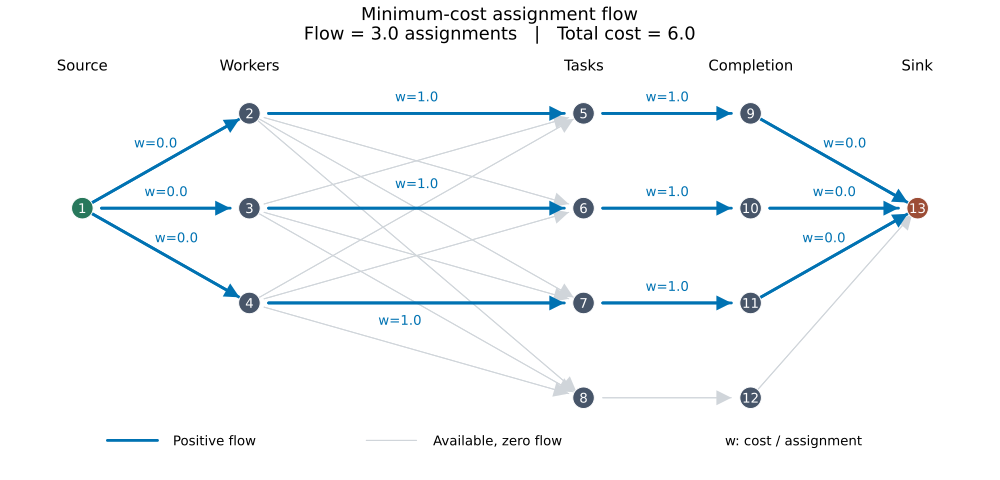

In [9]:
# Highlight selected assignments and show costs along their network paths -
plot_cost_flow(edges, result, node_coordinates)


For the supplied data, trace the route `1 → 2 → 5 → 9 → 13`. It assigns worker `2` to task `5`, then records completion and delivers one assignment to the sink. The two positive edge costs on this route add to two cost units. The other two selected routes have the same cost, consistent with the six-unit total in the cost table.

Task `8` and its completion node `12` carry no flow. This is consistent with completing three assignments when four tasks are available. Identify the source and task-completion edges whose capacities prevent a worker or task from receiving two assignments. In Task 3, we will remove one selected worker–task option and examine how the remaining assignments change.


___

## Task 3: Sensitivity when an assignment becomes unavailable

In this task, we block the edge from worker `4` to task `7` and find the least-cost assignment for the same required flow. Comparing the original and revised solutions will show why changing one worker's options can change another worker's task. We then block each worker–task edge in turn to see which assignments the solution depends on, and finish by removing a worker entirely.

For the supplied data, worker `4` originally performs task `7`. Setting both bounds on edge $(4,7)$ to zero removes that option. Worker `4` can still perform other tasks; all other bounds, costs, and the required flow stay fixed.

__Before running:__ Can we still complete three assignments? If worker `4` takes task `6`, which worker must change tasks? Sketch a feasible assignment for all three workers.

[The `block_assignments(...)` function](docs/block_assignments.md) returns a copy of `edges` with both bounds on the listed edges set to zero; the original network stays unchanged for comparison. We block the one edge and re-solve with [the `solve_min_cost_flow(...)` function](docs/solve_min_cost_flow.md):


In [10]:
blocked_assignment = (4, 7); # unavailable (worker node, task node)
@assert haskey(result.flow, blocked_assignment) # check that this edge exists

# Block the edge in a copy of the network and re-solve for the same required flow -
disrupted_edges = block_assignments(edges, [blocked_assignment]);
disrupted_result = solve_min_cost_flow(disrupted_edges, 1, 13, required_flow);
disrupted_assignments = selected_assignments(disrupted_result);

### Compare the assignments

Each row shows one worker's original and revised tasks, along with their worker–task costs. Completion costs are accounted for after the table. With the supplied unit capacities, each worker has at most one task; a worker with no task is marked `unassigned` and has zero worker–task cost.

We fill the table with two loops, one for each solution. Both use the unchanged unit costs in `edge_costs` from Task 2:


In [11]:
# Start with one row per worker, no assigned task, and zero cost -
assignment_comparison = DataFrame(
    worker = collect(2:4),
    baseline_task = fill("unassigned", 3),
    revised_task = fill("unassigned", 3),
    baseline_cost = zeros(3),
    revised_cost = zeros(3),
);

# Fill the original tasks and worker–task costs -
for item in assignments
    row = item.worker - 1; # worker nodes 2, 3, 4 occupy rows 1, 2, 3
    unit_cost = edge_costs[(item.worker, item.task)];
    assignment_comparison.baseline_task[row] = string(item.task);
    assignment_comparison.baseline_cost[row] = unit_cost * item.flow;
end

# Fill the revised tasks using the same unit costs -
for item in disrupted_assignments
    row = item.worker - 1;
    unit_cost = edge_costs[(item.worker, item.task)];
    assignment_comparison.revised_task[row] = string(item.task);
    assignment_comparison.revised_cost[row] = unit_cost * item.flow;
end;


Let's display the original and revised assignments:


In [12]:
# Display the original and revised assignments -
pretty_table(HTML, assignment_comparison;
    column_labels = ["Worker", "Original task", "New task", "Original cost", "New cost"],
    alignment = :r,
    formatters = [fmt__round(4, 4:5)],
)


Worker,Original task,New task,Original cost,New cost
2,5,5,1.0,1.0
3,6,8,1.0,2.0
4,7,6,1.0,3.0


For the supplied data, worker `2` keeps task `5`. Worker `4` moves to task `6`, so worker `3` moves from task `6` to task `8`. Task `7` is left unassigned. Two workers change tasks because task `6` can accept only one worker.


### Explain the change in total cost

The new-cost column totals $1+2+3=6$ cost units for the worker–task edges, compared with $1+1+1=3$ originally. Task completion adds three cost units to both solutions, because both complete three assignments; the source and sink edges cost zero. Let's confirm the two totals from the solver results:


In [13]:
# Compare the reported totals; all amounts are in cost units -
(original_cost = result.cost, revised_cost = disrupted_result.cost,
 change = disrupted_result.cost - result.cost)

(original_cost = 6.0, revised_cost = 9.0, change = 3.0)

For the supplied data, blocking one edge raised the total cost from six to nine. Keeping workers `2` and `3` on tasks `5` and `6` would leave task `8` for worker `4`. The worker–task costs would then total $1+1+5=7$; adding three cost units for completion gives a total of ten. Moving worker `3` to task `8` frees task `6` for worker `4` and gives the lower total of nine. Changing only worker `4` would miss this cheaper assignment.

If you change the costs or the blocked edge, interpret the values in the updated tables.


### Check the revised solution

[The `validate_flow_solution(...)` function](docs/validate_flow.md) checks edge bounds, recomputes node balances, and compares the recomputed cost with the solver's reported cost. We apply it to the revised solution in the revised network, confirm that the blocked edge carries no flow and that the flows are whole assignments, and then ask whether the original solution is still feasible after the change:


In [14]:
# Check the revised solution using the revised network -
disrupted_validation = validate_flow_solution(disrupted_edges, disrupted_result; atol = check_tolerance);
@test disrupted_result.status == MathOptInterface.OPTIMAL;
@test disrupted_validation.valid; # edge bounds, node balances, and cost accounting
@test abs(disrupted_result.flow[blocked_assignment]) <= check_tolerance; # the blocked edge carries no flow
@test all(isapprox(value, round(value); atol = check_tolerance, rtol = 0.0)
    for value in disrupted_result.vector); # whole assignments, without rounding the solution

# Check whether the original solution is still feasible in the revised network -
old_solution_check = validate_flow_solution(disrupted_edges, result; atol = check_tolerance);
(old_solution_still_feasible = old_solution_check.valid,
 maximum_balance_residual = disrupted_validation.maximum_balance_residual)

(old_solution_still_feasible = false, maximum_balance_residual = 0.0)

For the supplied data, `old_solution_still_feasible` is `false` because the original solution used the blocked edge $(4,7)$, which now has an upper bound of zero. The revised solution passes the checks with a zero balance residual: it still completes three assignments, but at a cost of nine.


### Which assignments can we afford to lose?

Losing edge $(4,7)$ cost three units. Is every lost edge that expensive? Let's block each of the twelve worker–task edges in turn, re-solve for the same required flow, and record the minimum cost and the new assignment for each case.

__Before running:__ Using the assignment table from Task 2, predict which edges can be blocked without changing the minimum cost. Which single blocked edge do you expect to be the most expensive?

The loop stores each solver result in `sweep_results`, keyed by the blocked edge, and one summary row per case in `sweep`. The `original_flow` column records whether the original solution used that edge:


In [15]:
# Block each worker–task edge in turn and re-solve for the same required flow -
worker_task_edges = [(edge.source, edge.target) for edge in edges if edge.source in 2:4 && edge.target in 5:8];
sweep_results = Dict{Tuple{Int64,Int64},Any}(); # solver result for each blocked edge
sweep = DataFrame(worker = Int64[], task = Int64[], original_flow = Float64[],
    revised_cost = Float64[], change = Float64[], revised_assignment = String[]);
for pair in worker_task_edges
    sweep_result = solve_min_cost_flow(block_assignments(edges, [pair]), 1, 13, required_flow);
    sweep_results[pair] = sweep_result;
    sweep_assignment = join(["$(item.worker) → $(item.task)" for item in selected_assignments(sweep_result)], ", ");
    push!(sweep, (pair[1], pair[2], result.flow[pair], sweep_result.cost,
        sweep_result.cost - result.cost, sweep_assignment));
end

Each row blocks one edge. A positive change means that losing the edge raised the minimum cost; a zero change means the solution did not need it. All costs are in cost units:


In [16]:
# Display one row per blocked worker–task edge -
pretty_table(HTML, sweep;
    column_labels = ["Worker", "Task", "Original flow", "Revised cost", "Change", "Revised assignment"],
    alignment = [:r, :r, :r, :r, :r, :l],
    formatters = [fmt__round(4, 3:5)],
)

Worker,Task,Original flow,Revised cost,Change,Revised assignment
2,5,1.0,8.0,2.0,"2 → 8, 3 → 6, 4 → 7"
2,6,0.0,6.0,0.0,"2 → 5, 3 → 6, 4 → 7"
2,7,0.0,6.0,0.0,"2 → 5, 3 → 6, 4 → 7"
2,8,0.0,6.0,0.0,"2 → 5, 3 → 6, 4 → 7"
3,5,0.0,6.0,0.0,"2 → 5, 3 → 6, 4 → 7"
3,6,1.0,7.0,1.0,"2 → 5, 3 → 8, 4 → 7"
3,7,0.0,6.0,0.0,"2 → 5, 3 → 6, 4 → 7"
3,8,0.0,6.0,0.0,"2 → 5, 3 → 6, 4 → 7"
4,5,0.0,6.0,0.0,"2 → 5, 3 → 6, 4 → 7"
4,6,0.0,6.0,0.0,"2 → 5, 3 → 6, 4 → 7"


For the supplied data, the nine edges with zero original flow leave the cost at six: the original assignment remains available, so the minimum cannot change. The three used edges are different. Losing $(3,6)$ raises the cost by one, losing $(2,5)$ by two, and losing $(4,7)$ by three, even though all three edges cost one unit per assignment. The increase is the extra cost of the cheapest replacement assignment, which moves only the affected worker for $(2,5)$ and $(3,6)$ but two workers for $(4,7)$; it is not the cost of the edge itself. No single lost edge makes three assignments infeasible, because every worker still has at least three available tasks.

The following tests check every case in the sweep: each solve was optimal and feasible, the blocked edge carries no flow, and the cost never fell below the original minimum. For the supplied costs, an unused edge leaves the cost unchanged and a used edge raises it:


In [17]:
@testset "Blocked-edge sweep" begin
    for row in eachrow(sweep)
        pair = (row.worker, row.task);
        sweep_result = sweep_results[pair];
        @test sweep_result.status == MathOptInterface.OPTIMAL
        @test validate_flow_solution(block_assignments(edges, [pair]), sweep_result; atol = check_tolerance).valid
        @test abs(sweep_result.flow[pair]) <= check_tolerance

        # With the same costs and required flow, blocking an edge cannot lower the minimum.
        @test sweep_result.cost >= result.cost - check_tolerance
        if row.original_flow <= check_tolerance
            @test isapprox(sweep_result.cost, result.cost; atol = check_tolerance, rtol = 0.0) # unused edge
        else
            @test sweep_result.cost > result.cost + check_tolerance # used edge, for the supplied costs
        end
    end
end;

Test Summary:      | Pass  Total  Time
Blocked-edge sweep |   60     60  0.0s


### What if a worker is unavailable?

Every single blocked edge left the problem feasible. Blocking all four of worker `4`'s edges is different: three assignments would need three workers, and only two remain. The source-only cut from the [maximum-flow sensitivity lab](../L5b/CHEME-5800-L5b-Lab-MaximumFlowSensitivity-Fall-2026.ipynb) still has capacity three, but no flow can leave worker `4`, so the maximum flow is two and the requirement $F=3$ cannot be met. The solver reports that the model is infeasible, and [the `solve_min_cost_flow(...)` function](docs/solve_min_cost_flow.md) stops with an error instead of returning a result. We check for that error with [the `@test_throws` macro](https://docs.julialang.org/en/v1/stdlib/Test/#Test.@test_throws):


In [18]:
# Block every task for worker 4; the required flow now exceeds what two workers can deliver -
outage_edges = block_assignments(edges, [(4, task) for task in 5:8]);
@test_throws ErrorException solve_min_cost_flow(outage_edges, 1, 13, required_flow)

Test Passed
      Thrown: ErrorException

The error is the right outcome: a required flow that the network cannot deliver has no feasible solution, and no assignment should be read from the model. This is the linear-programming form of the worker outage from the maximum-flow sensitivity lab, where the same loss reduced the maximum flow from three to two.


___

## Summary

In this lab, we formulated worker–task assignment as a minimum-cost flow problem and used feasibility checks and cost comparisons to interpret how the allocation responds to changes in the available assignments.

> __Key Takeaways__
>
> * __From assignment rules to a flow model:__ We used the incidence matrix, edge bounds, and required flow to express the assignment constraints. This separated how much work must be completed from how it is allocated, while the objective accounted for costs along each selected path.
>
> * __Feasibility and optimality:__ We checked edge bounds and node balances, confirmed that the flows were whole assignments, and recomputed the total cost of six from the original edge costs. These checks establish feasibility, and a separate lower-bound argument showed that no three-assignment solution can cost less than six.
>
> * __Effects of restricting assignments:__ We blocked each worker–task edge in turn and re-solved for the same required flow: the nine unused edges left the cost at six, while losing a used edge raised it by one, two, or three, the extra cost of the cheapest replacement assignment rather than the cost of the edge itself. Removing all of one worker's options made three assignments infeasible, and no restriction can lower the minimum cost.
